In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils.knn import KNN
from utils.metrics_evaluator import MetricsEvaluator
from utils.helpers import bulk_min_max_normalization, to_percent

In [2]:
def drawHistogram(df: pd.DataFrame, col: str):
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribusi Data {col}')
    plt.show()

In [3]:
def drawBoxPlot(df: pd.DataFrame):
    plt.figure(figsize=(8, 6))
    numeric_df = df.select_dtypes(include=[np.number])
    numeric_df.boxplot()
    plt.title("Box Plot Setiap Fitur")
    plt.ylabel("Nilai")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.show()


    # plt.figure(figsize=(6, 4))
    # sns.boxplot(x=df[col].dropna())
    # plt.title(f'Boxplot Data {col}')
    # plt.show()

In [4]:
# dm2 anu murni dm2 hngkl
# dm2-all anu boga panyakit lain diasupken, tuluy direname
# df = pd.read_csv("dataset-dm2.csv")
df = pd.read_csv("new_dataset.csv")[['age', 'gender', 'systolic_bp', 'diastolic_bp', 'glucose', 'diabetic']].set_axis(['umur', 'jenis_kelamin','sistolik','diastolik','glukosa','diagnosa'],axis=1)
df

,umur,jenis_kelamin,sistolik,diastolik,glukosa,diagnosa
0,42,Female,110,73,5.88,No
1,35,Female,125,68,5.71,No
2,62,Female,127,74,6.85,No
3,73,Male,193,112,6.28,No
4,68,Female,150,81,5.71,No
...,...,...,...,...,...,...
5432,74,Male,164,89,6.47,No
5433,75,Male,141,104,8.31,Yes
5434,40,Female,134,114,7.61,No
5435,36,Female,139,80,4.90,No


In [8]:
jumlah_diagnosa = df['diagnosa'].value_counts()

print(f"No  : {jumlah_diagnosa.get('No', 0)}")
print(f"Yes : {jumlah_diagnosa.get('Yes', 0)}")

No  : 5093
Yes : 344


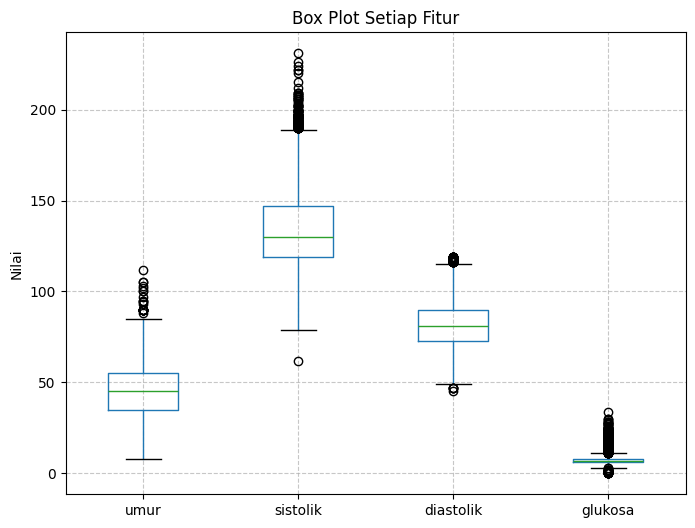

In [9]:
drawBoxPlot(df)

In [10]:
missingSistolikCount = df['sistolik'].isna().sum()
print(missingSistolikCount)

0


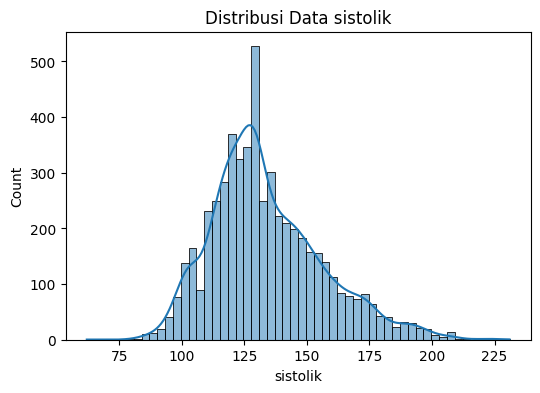

In [11]:
drawHistogram(df, 'sistolik')

In [12]:
# Filling missing 'sistolik' values with the mean
df['sistolik'] = df['sistolik'].fillna(df['sistolik'].mean())
df

,umur,jenis_kelamin,sistolik,diastolik,glukosa,diagnosa
0,42,Female,110,73,5.88,No
1,35,Female,125,68,5.71,No
2,62,Female,127,74,6.85,No
3,73,Male,193,112,6.28,No
4,68,Female,150,81,5.71,No
...,...,...,...,...,...,...
5432,74,Male,164,89,6.47,No
5433,75,Male,141,104,8.31,Yes
5434,40,Female,134,114,7.61,No
5435,36,Female,139,80,4.90,No


In [13]:
missingDiastolikCount = df['diastolik'].isna().sum()
print(missingDiastolikCount)

0


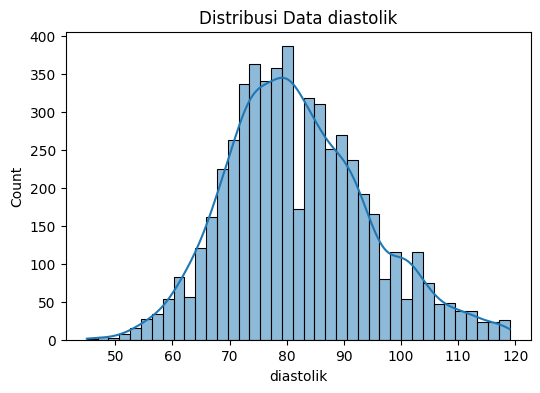

In [14]:
drawHistogram(df, 'diastolik')

In [15]:
# Mengisi nilai yang hilang pada kolom Diastolik dengan nilai rata-rata mean (nilai rata-rata)
df['diastolik'] = df['diastolik'].fillna(df['diastolik'].mean())
df

,umur,jenis_kelamin,sistolik,diastolik,glukosa,diagnosa
0,42,Female,110,73,5.88,No
1,35,Female,125,68,5.71,No
2,62,Female,127,74,6.85,No
3,73,Male,193,112,6.28,No
4,68,Female,150,81,5.71,No
...,...,...,...,...,...,...
5432,74,Male,164,89,6.47,No
5433,75,Male,141,104,8.31,Yes
5434,40,Female,134,114,7.61,No
5435,36,Female,139,80,4.90,No


In [16]:
missingGdsCount = df['glukosa'].isna().sum()
print(missingGdsCount)

0


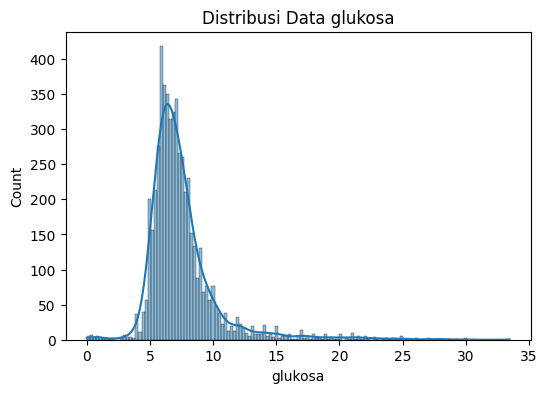

In [17]:
drawHistogram(df, 'glukosa')

In [18]:
# Mengisi nilai yang hilang pada kolom glukosa dengan nilai median (nilai tengah)
df['glukosa'] = df['glukosa'].fillna(df['glukosa'].median())
df

,umur,jenis_kelamin,sistolik,diastolik,glukosa,diagnosa
0,42,Female,110,73,5.88,No
1,35,Female,125,68,5.71,No
2,62,Female,127,74,6.85,No
3,73,Male,193,112,6.28,No
4,68,Female,150,81,5.71,No
...,...,...,...,...,...,...
5432,74,Male,164,89,6.47,No
5433,75,Male,141,104,8.31,Yes
5434,40,Female,134,114,7.61,No
5435,36,Female,139,80,4.90,No


In [19]:
missingGenderCount = df['jenis_kelamin'].isna().sum()
print(missingGenderCount)

0


In [20]:
uniqueGenderValuesCount = df['jenis_kelamin'].nunique()
uniqueGenderValues = np.array(df['jenis_kelamin'].unique())

print(f"Jumlah nilai unik pada kolom 'jenis_kelamin': {uniqueGenderValuesCount}")
print(f"Nilai unik pada kolom 'jenis_kelamin': {uniqueGenderValues}")

Jumlah nilai unik pada kolom 'jenis_kelamin': 2
Nilai unik pada kolom 'jenis_kelamin': ['Female' 'Male']


In [21]:
# Mengisi nilai yang hilang pada kolom jenis_kelamin dengan nilai modus (nilai yang sering mucul)
df['jenis_kelamin'] = df['jenis_kelamin'].fillna(df['jenis_kelamin'].mode()[0])
df

,umur,jenis_kelamin,sistolik,diastolik,glukosa,diagnosa
0,42,Female,110,73,5.88,No
1,35,Female,125,68,5.71,No
2,62,Female,127,74,6.85,No
3,73,Male,193,112,6.28,No
4,68,Female,150,81,5.71,No
...,...,...,...,...,...,...
5432,74,Male,164,89,6.47,No
5433,75,Male,141,104,8.31,Yes
5434,40,Female,134,114,7.61,No
5435,36,Female,139,80,4.90,No


In [22]:
# Mapping Gender: Female to 1, Male to 0
df['transformed_gender'] = df['jenis_kelamin'].map(lambda e: 1 if e == 'Female' else 0)
df

,umur,jenis_kelamin,sistolik,diastolik,glukosa,diagnosa,transformed_gender
0,42,Female,110,73,5.88,No,1
1,35,Female,125,68,5.71,No,1
2,62,Female,127,74,6.85,No,1
3,73,Male,193,112,6.28,No,0
4,68,Female,150,81,5.71,No,1
...,...,...,...,...,...,...,...
5432,74,Male,164,89,6.47,No,0
5433,75,Male,141,104,8.31,Yes,0
5434,40,Female,134,114,7.61,No,1
5435,36,Female,139,80,4.90,No,1


In [23]:
missingYearCount = df['umur'].isna().sum()
print(missingYearCount)

0


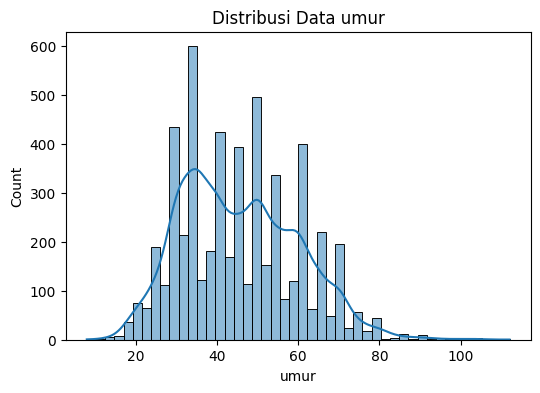

In [24]:
drawHistogram(df, 'umur')

In [25]:
# Mengisi nilai yang hilang pada kolom umur dengan nilai median (nilai tengah)
df['umur'] = df['umur'].fillna(df['umur'].median())
df

,umur,jenis_kelamin,sistolik,diastolik,glukosa,diagnosa,transformed_gender
0,42,Female,110,73,5.88,No,1
1,35,Female,125,68,5.71,No,1
2,62,Female,127,74,6.85,No,1
3,73,Male,193,112,6.28,No,0
4,68,Female,150,81,5.71,No,1
...,...,...,...,...,...,...,...
5432,74,Male,164,89,6.47,No,0
5433,75,Male,141,104,8.31,Yes,0
5434,40,Female,134,114,7.61,No,1
5435,36,Female,139,80,4.90,No,1


In [26]:
uniqueDiagnoseValuesCount = df['diagnosa'].nunique()
uniqueDiagnoseValues = np.array(df['diagnosa'].unique())

print(f"Jumlah nilai unik pada kolom 'diagnosa': {uniqueDiagnoseValuesCount}")
print(f"Nilai unik pada kolom 'diagnosa': {uniqueDiagnoseValues}")

Jumlah nilai unik pada kolom 'diagnosa': 2
Nilai unik pada kolom 'diagnosa': ['No' 'Yes']


In [27]:
df['diagnosa'] = df['diagnosa'].map(lambda e: 1 if e == 'Yes' else 0)
df

,umur,jenis_kelamin,sistolik,diastolik,glukosa,diagnosa,transformed_gender
0,42,Female,110,73,5.88,0,1
1,35,Female,125,68,5.71,0,1
2,62,Female,127,74,6.85,0,1
3,73,Male,193,112,6.28,0,0
4,68,Female,150,81,5.71,0,1
...,...,...,...,...,...,...,...
5432,74,Male,164,89,6.47,0,0
5433,75,Male,141,104,8.31,1,0
5434,40,Female,134,114,7.61,0,1
5435,36,Female,139,80,4.90,0,1


In [28]:
# Normalisasi kolom sistolik

df['norm_sistolik'] = bulk_min_max_normalization(df['sistolik'])
df

,umur,jenis_kelamin,sistolik,diastolik,glukosa,diagnosa,transformed_gender,norm_sistolik
0,42,Female,110,73,5.88,0,1,0.284024
1,35,Female,125,68,5.71,0,1,0.372781
2,62,Female,127,74,6.85,0,1,0.384615
3,73,Male,193,112,6.28,0,0,0.775148
4,68,Female,150,81,5.71,0,1,0.520710
...,...,...,...,...,...,...,...,...
5432,74,Male,164,89,6.47,0,0,0.603550
5433,75,Male,141,104,8.31,1,0,0.467456
5434,40,Female,134,114,7.61,0,1,0.426036
5435,36,Female,139,80,4.90,0,1,0.455621


In [29]:
# Normalisasi kolom diastolik
df['norm_diastolik'] = bulk_min_max_normalization(df['diastolik'])
df

,umur,jenis_kelamin,sistolik,diastolik,glukosa,diagnosa,transformed_gender,norm_sistolik,norm_diastolik
0,42,Female,110,73,5.88,0,1,0.284024,0.378378
1,35,Female,125,68,5.71,0,1,0.372781,0.310811
2,62,Female,127,74,6.85,0,1,0.384615,0.391892
3,73,Male,193,112,6.28,0,0,0.775148,0.905405
4,68,Female,150,81,5.71,0,1,0.520710,0.486486
...,...,...,...,...,...,...,...,...,...
5432,74,Male,164,89,6.47,0,0,0.603550,0.594595
5433,75,Male,141,104,8.31,1,0,0.467456,0.797297
5434,40,Female,134,114,7.61,0,1,0.426036,0.932432
5435,36,Female,139,80,4.90,0,1,0.455621,0.472973


In [30]:
# Normalisasi kolom Umur
df['norm_umur'] = bulk_min_max_normalization(df['umur'])
df

,umur,jenis_kelamin,sistolik,diastolik,glukosa,diagnosa,transformed_gender,norm_sistolik,norm_diastolik,norm_umur
0,42,Female,110,73,5.88,0,1,0.284024,0.378378,0.326923
1,35,Female,125,68,5.71,0,1,0.372781,0.310811,0.259615
2,62,Female,127,74,6.85,0,1,0.384615,0.391892,0.519231
3,73,Male,193,112,6.28,0,0,0.775148,0.905405,0.625000
4,68,Female,150,81,5.71,0,1,0.520710,0.486486,0.576923
...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,164,89,6.47,0,0,0.603550,0.594595,0.634615
5433,75,Male,141,104,8.31,1,0,0.467456,0.797297,0.644231
5434,40,Female,134,114,7.61,0,1,0.426036,0.932432,0.307692
5435,36,Female,139,80,4.90,0,1,0.455621,0.472973,0.269231


In [31]:
# Normalisasi kolom glukosa
df['norm_glukosa'] = bulk_min_max_normalization(df['glukosa'])
df

,umur,jenis_kelamin,sistolik,diastolik,glukosa,diagnosa,transformed_gender,norm_sistolik,norm_diastolik,norm_umur,norm_glukosa
0,42,Female,110,73,5.88,0,1,0.284024,0.378378,0.326923,0.175732
1,35,Female,125,68,5.71,0,1,0.372781,0.310811,0.259615,0.170652
2,62,Female,127,74,6.85,0,1,0.384615,0.391892,0.519231,0.204722
3,73,Male,193,112,6.28,0,0,0.775148,0.905405,0.625000,0.187687
4,68,Female,150,81,5.71,0,1,0.520710,0.486486,0.576923,0.170652
...,...,...,...,...,...,...,...,...,...,...,...
5432,74,Male,164,89,6.47,0,0,0.603550,0.594595,0.634615,0.193365
5433,75,Male,141,104,8.31,1,0,0.467456,0.797297,0.644231,0.248356
5434,40,Female,134,114,7.61,0,1,0.426036,0.932432,0.307692,0.227436
5435,36,Female,139,80,4.90,0,1,0.455621,0.472973,0.269231,0.146444


newDf ini adalah cerminan dari dataset mentah yang sudah ditambahkan kolom transformasi dan normalisasi

In [32]:
newDf = df[['umur', 'sistolik', 'diastolik', 'glukosa', 'transformed_gender', 'norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_glukosa', 'diagnosa']]
newDf

,umur,sistolik,diastolik,glukosa,transformed_gender,norm_sistolik,norm_diastolik,norm_umur,norm_glukosa,diagnosa
0,42,110,73,5.88,1,0.284024,0.378378,0.326923,0.175732,0
1,35,125,68,5.71,1,0.372781,0.310811,0.259615,0.170652,0
2,62,127,74,6.85,1,0.384615,0.391892,0.519231,0.204722,0
3,73,193,112,6.28,0,0.775148,0.905405,0.625000,0.187687,0
4,68,150,81,5.71,1,0.520710,0.486486,0.576923,0.170652,0
...,...,...,...,...,...,...,...,...,...,...
5432,74,164,89,6.47,0,0.603550,0.594595,0.634615,0.193365,0
5433,75,141,104,8.31,0,0.467456,0.797297,0.644231,0.248356,1
5434,40,134,114,7.61,1,0.426036,0.932432,0.307692,0.227436,0
5435,36,139,80,4.90,1,0.455621,0.472973,0.269231,0.146444,0


In [33]:
newDf.to_csv("dataset_preprocessed.csv", index=False)

# Evaluasi Dataset
Mulai dari membaca csv yang sudah diekspor

In [34]:
readyDf = pd.read_csv("dataset_preprocessed.csv")[['transformed_gender', 'norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_glukosa', 'diagnosa']]
readyDf

,transformed_gender,norm_sistolik,norm_diastolik,norm_umur,norm_glukosa,diagnosa
0,1,0.284024,0.378378,0.326923,0.175732,0
1,1,0.372781,0.310811,0.259615,0.170652,0
2,1,0.384615,0.391892,0.519231,0.204722,0
3,0,0.775148,0.905405,0.625000,0.187687,0
4,1,0.520710,0.486486,0.576923,0.170652,0
...,...,...,...,...,...,...
5432,0,0.603550,0.594595,0.634615,0.193365,0
5433,0,0.467456,0.797297,0.644231,0.248356,1
5434,1,0.426036,0.932432,0.307692,0.227436,0
5435,1,0.455621,0.472973,0.269231,0.146444,0


In [35]:
class DatasetEvaluator:
    def __init__(self, df: pd.DataFrame, training_size: float):
        self.df = df
        self.training_size = int(df.shape[0] * training_size)
    
    def split_datasets(self):
        # Memisahkan fitur (X) dan target (y)
        X = self.df[['norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_glukosa', 'transformed_gender']]
        y = self.df['diagnosa']

        # Membagi dataset menjadi data Latih (Train) dan data Uji (Test)
        self.X_train = X.iloc[:self.training_size]
        self.y_train = y.iloc[:self.training_size]
        self.X_test = X.iloc[self.training_size:]
        self.y_test = y.iloc[self.training_size:]

        print("Dimensi data latih - {},{}".format(self.X_train.shape, self.y_train.shape))
        print("Dimensi data validasi - {},{}".format(self.X_test.shape, self.y_test.shape))
        
    def evaluate_knn(self):
        # Iterate through different K values and distance metrics to evaluate performance
        for k_count in np.array([3, 5, 7, 9]):
            knn = KNN(k=k_count)
            knn.fit(self.X_train, self.y_train)

            predictions = knn.predict(self.X_test.values)
            y_pred = predictions['Euclidean']
            
            # for distance_type, y_pred in predictions.items(): -> uncomment this if want to use all distance types
            evaluator = MetricsEvaluator(y_pred, self.y_test.values)
            evaluator.plot_confusion_matrix(title=f"Confusion Matrix - Jarak Euclidean (K={k_count})")
            accuracy = evaluator.accuracy()
            precision = evaluator.precision()
            recall = evaluator.recall()
            f1_score = evaluator.f1_score()

            print(f"Results for Euclidean Distance (K={k_count})")
            print(f"Accuracy: {to_percent(accuracy)}, Precision: {to_percent(precision)}, Recall: {to_percent(recall)}, F1-Score: {to_percent(f1_score)}")
            print("-" * 80)

# Pembagian Data
Membagi dataset dengan komposisi train:test dengan beberapa skenario, di antaranya 80:20, 75:25, 90:10

# 80:20

Dimensi data latih - (4349, 5),(4349,)
Dimensi data validasi - (1088, 5),(1088,)
Results for Euclidean Distance (K=3)
Accuracy: 92.10%, Precision: 29.63%, Recall: 10.67%, F1-Score: 15.69%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=5)
Accuracy: 92.46%, Precision: 26.67%, Recall: 5.33%, F1-Score: 8.89%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=7)
Accuracy: 92.92%, Precision: 42.86%, Recall: 8.00%, F1-Score: 13.48%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=9)
Accuracy: 93.11%, Precision: 50.00%, Recall: 6.67%, F1-Score: 11.76%
--------------------------------------------------------------------------------


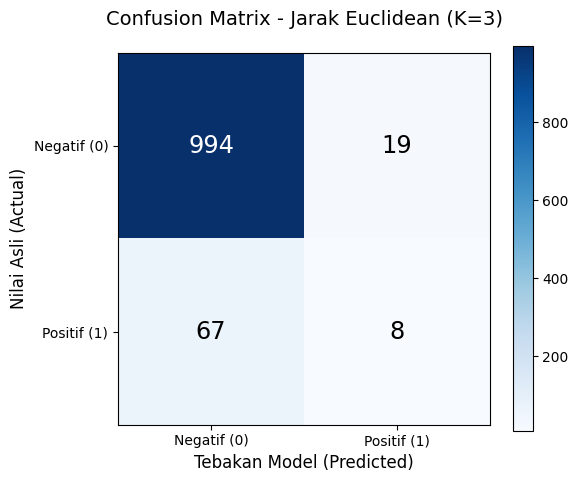

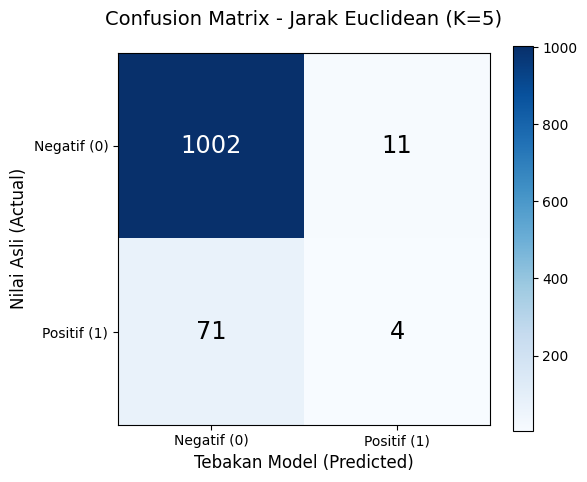

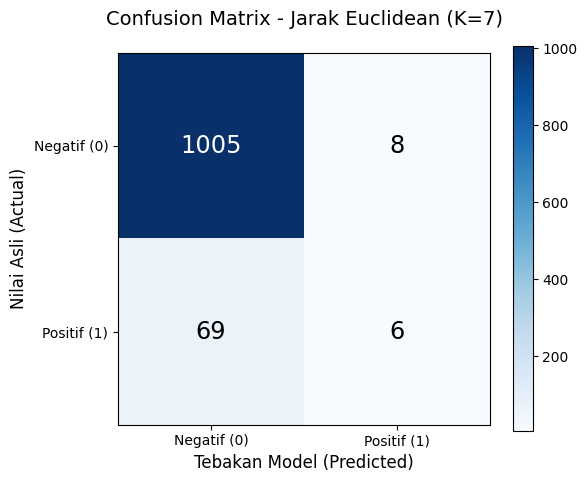

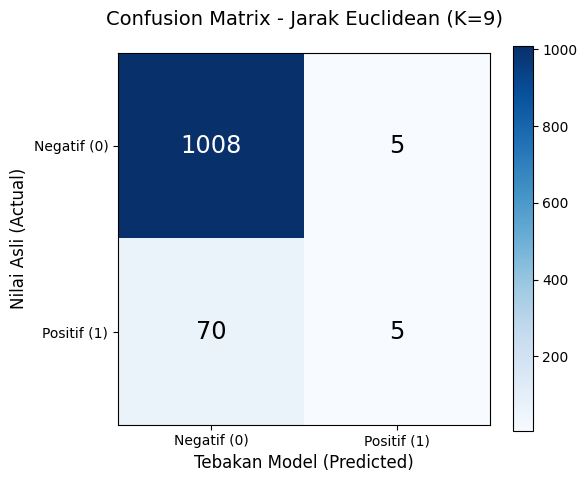

In [36]:
datasetEighty = DatasetEvaluator(readyDf, training_size=0.8)
datasetEighty.split_datasets()
datasetEighty.evaluate_knn()

# 75:25

Dimensi data latih - (4077, 5),(4077,)
Dimensi data validasi - (1360, 5),(1360,)
Results for Euclidean Distance (K=3)
Accuracy: 92.72%, Precision: 35.48%, Recall: 12.22%, F1-Score: 18.18%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=5)
Accuracy: 93.16%, Precision: 42.86%, Recall: 10.00%, F1-Score: 16.22%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=7)
Accuracy: 93.31%, Precision: 47.06%, Recall: 8.89%, F1-Score: 14.95%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=9)
Accuracy: 93.53%, Precision: 57.14%, Recall: 8.89%, F1-Score: 15.38%
--------------------------------------------------------------------------------


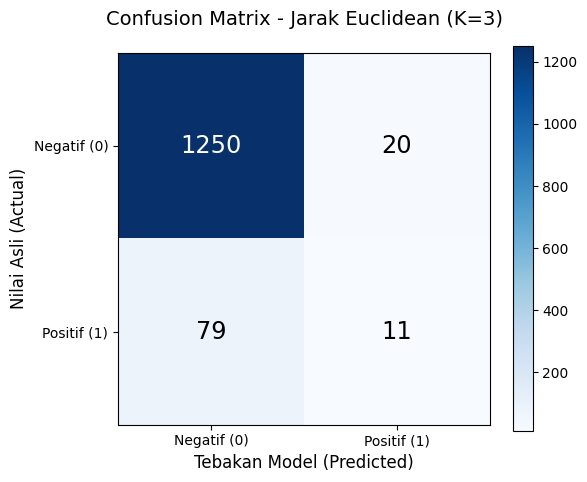

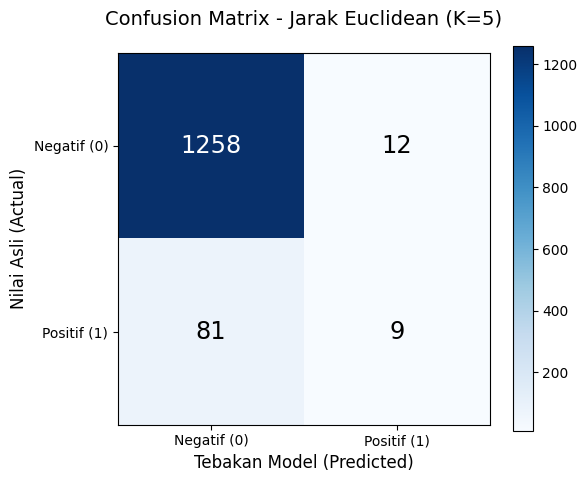

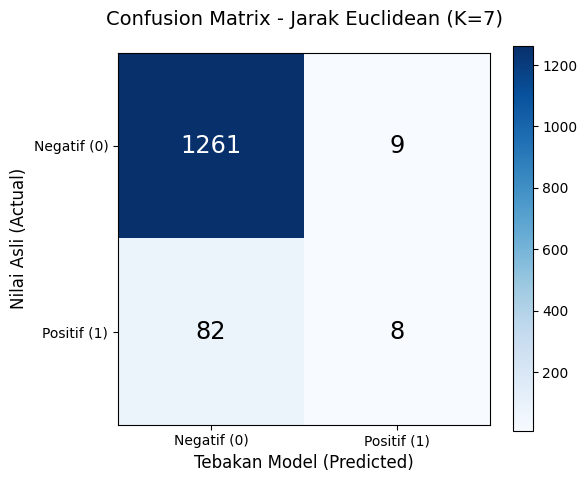

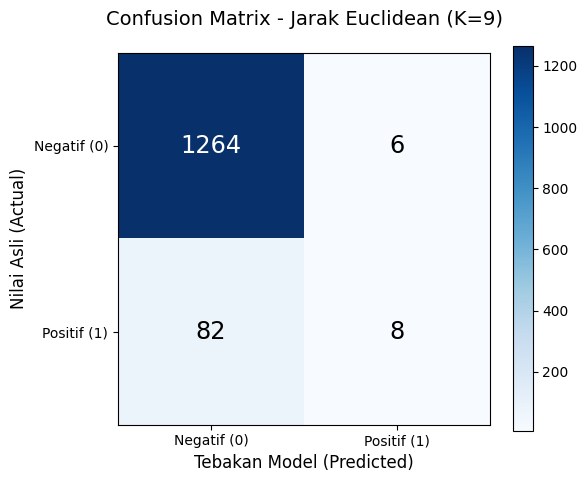

In [37]:
datasetSeventyFive = DatasetEvaluator(readyDf, training_size=0.75)
datasetSeventyFive.split_datasets()
datasetSeventyFive.evaluate_knn()

# 90:10

Dimensi data latih - (4893, 5),(4893,)
Dimensi data validasi - (544, 5),(544,)
Results for Euclidean Distance (K=3)
Accuracy: 91.73%, Precision: 20.00%, Recall: 5.13%, F1-Score: 8.16%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=5)
Accuracy: 92.10%, Precision: 16.67%, Recall: 2.56%, F1-Score: 4.44%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=7)
Accuracy: 92.46%, Precision: 25.00%, Recall: 2.56%, F1-Score: 4.65%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=9)
Accuracy: 92.28%, Precision: 20.00%, Recall: 2.56%, F1-Score: 4.55%
--------------------------------------------------------------------------------


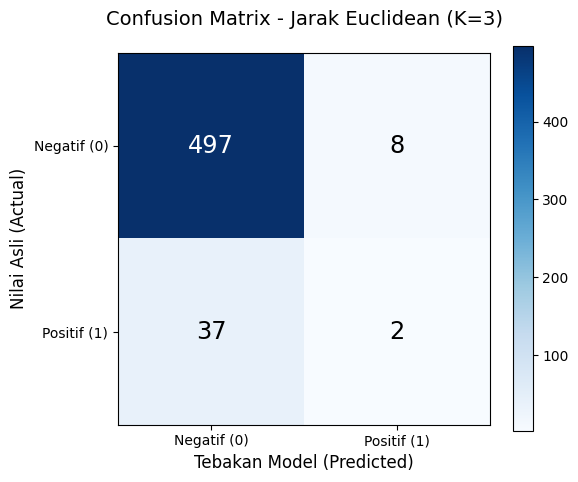

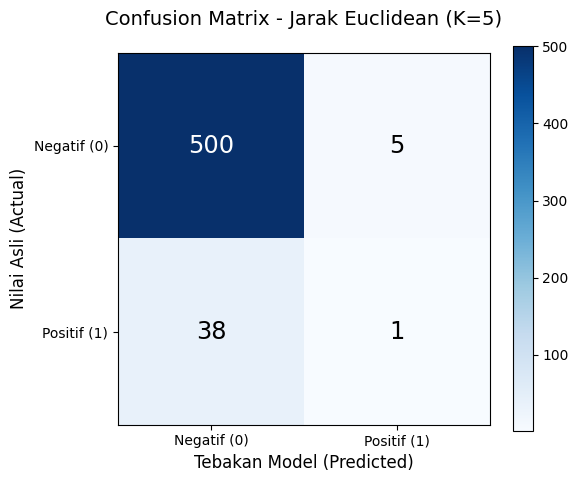

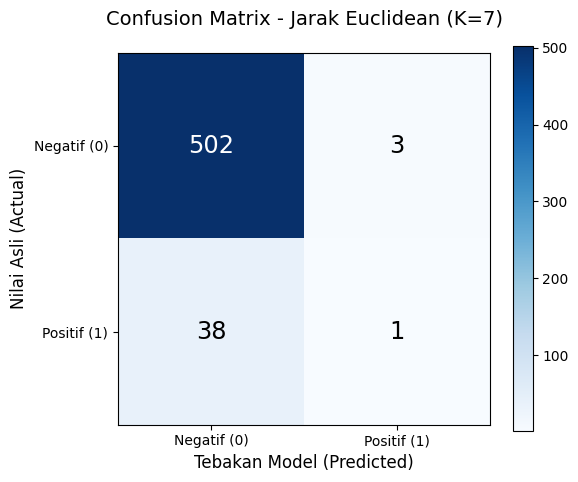

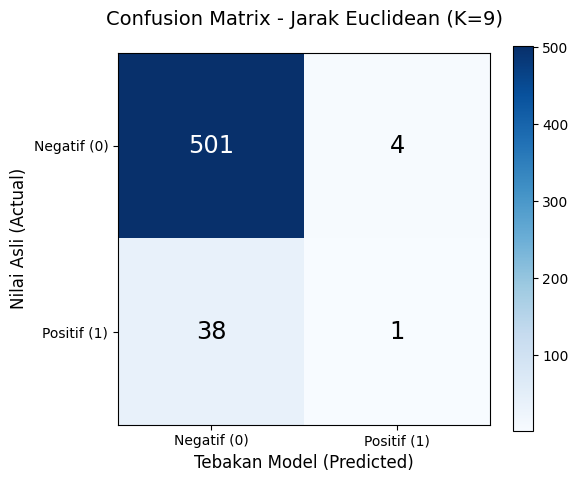

In [38]:
datasetNinety = DatasetEvaluator(readyDf, training_size=0.9)
datasetNinety.split_datasets()
datasetNinety.evaluate_knn()

# K-Fold Cross Validation => K = 4, 5, 10

In [39]:
K = np.array([4, 5, 10])

In [40]:
kFoldDf = pd.read_csv("dataset_preprocessed.csv")[['transformed_gender', 'norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_glukosa', 'diagnosa']]
kFoldDf

,transformed_gender,norm_sistolik,norm_diastolik,norm_umur,norm_glukosa,diagnosa
0,1,0.284024,0.378378,0.326923,0.175732,0
1,1,0.372781,0.310811,0.259615,0.170652,0
2,1,0.384615,0.391892,0.519231,0.204722,0
3,0,0.775148,0.905405,0.625000,0.187687,0
4,1,0.520710,0.486486,0.576923,0.170652,0
...,...,...,...,...,...,...
5432,0,0.603550,0.594595,0.634615,0.193365,0
5433,0,0.467456,0.797297,0.644231,0.248356,1
5434,1,0.426036,0.932432,0.307692,0.227436,0
5435,1,0.455621,0.472973,0.269231,0.146444,0


In [41]:
X = kFoldDf[['norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_glukosa', 'transformed_gender']]
y = kFoldDf['diagnosa']

In [42]:
from sklearn.model_selection import StratifiedKFold

results_storage = []

for k_count in K:
    # Buat objek Stratified K-Fold
    skf = StratifiedKFold(n_splits=k_count, shuffle=True, random_state=42)
    
    for fold_index, (train_idx, test_idx) in enumerate(list(skf.split(X,y))):
        k_X_train, k_X_test = X.iloc[train_idx], X.iloc[test_idx]
        k_y_train, k_y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        for k_knn in np.array([3, 5, 7, 9]):
            print(f"Fold {fold_index + 1}/{k_count} - K={k_knn}")
            knn = KNN(k=k_knn)
            knn.fit(k_X_train, k_y_train)

            predictions = knn.predict(k_X_test.values)
            y_pred = predictions['Euclidean']
            
            evaluator = MetricsEvaluator(y_pred, k_y_test.values)
            
            results_storage.append({
                'K_Fold': k_count,
                'Fold': fold_index + 1,
                'K_KNN': k_knn,
                'Distance': 'Euclidean',
                'Accuracy': evaluator.accuracy(),
                'Precision': evaluator.precision(),
                'Recall': evaluator.recall(),
                'F1_Score': evaluator.f1_score()
            })

Fold 1/4 - K=3
Fold 1/4 - K=5
Fold 1/4 - K=7
Fold 1/4 - K=9
Fold 2/4 - K=3
Fold 2/4 - K=5
Fold 2/4 - K=7
Fold 2/4 - K=9
Fold 3/4 - K=3
Fold 3/4 - K=5
Fold 3/4 - K=7
Fold 3/4 - K=9
Fold 4/4 - K=3
Fold 4/4 - K=5
Fold 4/4 - K=7
Fold 4/4 - K=9
Fold 1/5 - K=3
Fold 1/5 - K=5
Fold 1/5 - K=7
Fold 1/5 - K=9
Fold 2/5 - K=3
Fold 2/5 - K=5
Fold 2/5 - K=7
Fold 2/5 - K=9
Fold 3/5 - K=3
Fold 3/5 - K=5
Fold 3/5 - K=7
Fold 3/5 - K=9
Fold 4/5 - K=3
Fold 4/5 - K=5
Fold 4/5 - K=7
Fold 4/5 - K=9
Fold 5/5 - K=3
Fold 5/5 - K=5
Fold 5/5 - K=7
Fold 5/5 - K=9
Fold 1/10 - K=3
Fold 1/10 - K=5
Fold 1/10 - K=7
Fold 1/10 - K=9
Fold 2/10 - K=3
Fold 2/10 - K=5
Fold 2/10 - K=7
Fold 2/10 - K=9
Fold 3/10 - K=3
Fold 3/10 - K=5
Fold 3/10 - K=7
Fold 3/10 - K=9
Fold 4/10 - K=3
Fold 4/10 - K=5
Fold 4/10 - K=7
Fold 4/10 - K=9
Fold 5/10 - K=3
Fold 5/10 - K=5
Fold 5/10 - K=7
Fold 5/10 - K=9
Fold 6/10 - K=3
Fold 6/10 - K=5
Fold 6/10 - K=7
Fold 6/10 - K=9
Fold 7/10 - K=3
Fold 7/10 - K=5
Fold 7/10 - K=7
Fold 7/10 - K=9
Fold 8/10 - 

In [43]:
df_results = pd.DataFrame(results_storage)
df_results

,K_Fold,Fold,K_KNN,Distance,Accuracy,Precision,Recall,F1_Score
0,4,1,3,Euclidean,0.927206,0.303030,0.116279,0.168067
1,4,1,5,Euclidean,0.933824,0.428571,0.139535,0.210526
2,4,1,7,Euclidean,0.934559,0.444444,0.139535,0.212389
3,4,1,9,Euclidean,0.935294,0.450000,0.104651,0.169811
4,4,2,3,Euclidean,0.929360,0.352941,0.139535,0.200000
...,...,...,...,...,...,...,...,...
71,10,9,9,Euclidean,0.933702,0.400000,0.117647,0.181818
72,10,10,3,Euclidean,0.926335,0.285714,0.117647,0.166667
73,10,10,5,Euclidean,0.930018,0.250000,0.058824,0.095238
74,10,10,7,Euclidean,0.933702,0.333333,0.058824,0.100000


In [44]:
sorted_df_results = df_results.sort_values(by=['Accuracy'], ascending=False).reset_index(drop=True)
sorted_df_results

,K_Fold,Fold,K_KNN,Distance,Accuracy,Precision,Recall,F1_Score
0,10,3,9,Euclidean,0.944853,0.750000,0.176471,0.285714
1,10,3,5,Euclidean,0.943015,0.615385,0.235294,0.340426
2,10,3,7,Euclidean,0.943015,0.636364,0.205882,0.311111
3,5,3,9,Euclidean,0.941122,0.666667,0.117647,0.200000
4,5,3,7,Euclidean,0.938362,0.545455,0.088235,0.151899
...,...,...,...,...,...,...,...,...
71,10,1,3,Euclidean,0.924632,0.230769,0.088235,0.127660
72,10,8,7,Euclidean,0.924494,0.000000,0.000000,0.000000
73,4,4,3,Euclidean,0.924209,0.270270,0.116279,0.162602
74,5,4,3,Euclidean,0.923643,0.294118,0.144928,0.194175


In [45]:
best_configs = sorted_df_results.iloc[0:2][['K_Fold', 'Fold', 'K_KNN']]
best_configs

,K_Fold,Fold,K_KNN
0,10,3,9
1,10,3,5


Fold 3/10 - K=9
Fold 3/10 - K=5


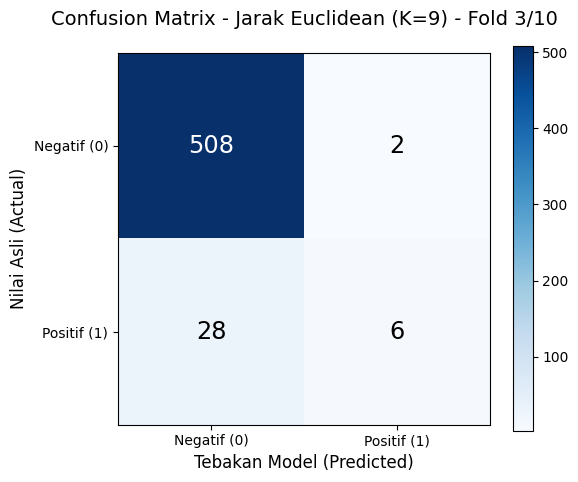

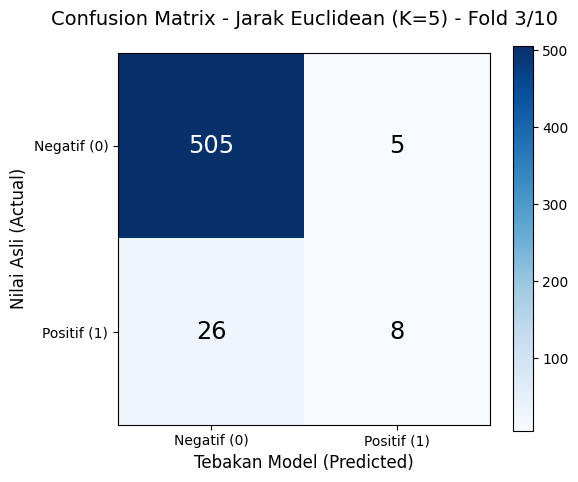

In [46]:
import joblib

skf = StratifiedKFold(n_splits=k_count, shuffle=True, random_state=42)

for best_config in best_configs.itertuples(index=False):
    for k_count in np.array([best_config.K_Fold]): # K-Fold Cross Validation
        for fold_index, (train_idx, test_idx) in enumerate(list(skf.split(X,y))):
            if(fold_index != best_config.Fold - 1): continue # nth Fold, -1 because index starts from 0
            
            best_X_train, best_X_test = X.iloc[train_idx], X.iloc[test_idx]
            best_y_train, best_y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            for k_knn in np.array([best_config.K_KNN]): # K KNN
                print(f"Fold {fold_index + 1}/{k_count} - K={k_knn}")
                knn = KNN(k=k_knn)
                knn.fit(best_X_train, best_y_train)
                knn.dump(best_X_test, best_y_test)  # Save the test data for later use
                joblib.dump(knn, "best_knn_model.joblib")

                predictions = knn.predict(best_X_test.values)
                best_y_pred = predictions['Euclidean']
                
                evaluator = MetricsEvaluator(best_y_pred, best_y_test.values)
                evaluator.plot_confusion_matrix(
                    title=f"Confusion Matrix - Jarak Euclidean (K={k_knn}) - Fold {fold_index + 1}/{k_count}"
                )

In [47]:
summary_results = df_results.groupby(['K_Fold', 'K_KNN'])[['Accuracy', 'Precision', 'Recall', 'F1_Score']].agg(['mean']).reset_index()
summary_results.columns = ['_'.join(col).strip('_') for col in summary_results.columns.values]
summary_results

,K_Fold,K_KNN,Accuracy_mean,Precision_mean,Recall_mean,F1_Score_mean
0,4,3,0.929189,0.352528,0.136628,0.196770
1,4,5,0.931763,0.356436,0.095930,0.150402
2,4,7,0.933787,0.404175,0.101744,0.161468
3,4,9,0.935074,0.437500,0.095930,0.157061
4,5,3,0.928453,0.337242,0.125021,0.180939
5,5,5,0.931580,0.349381,0.093009,0.145755
6,5,7,0.933603,0.392063,0.087212,0.141381
7,5,9,0.935442,0.449020,0.084399,0.141694
8,10,3,0.928637,0.340204,0.136471,0.192063
9,10,5,0.931579,0.348977,0.098908,0.152731


In [48]:
sorted_kfold = summary_results.sort_values(by='Accuracy_mean', ascending=False)

print(f"K-Fold      : {sorted_kfold.iloc[0]['K_Fold']}")
print(f"K-KNN       : {sorted_kfold.iloc[0]['K_KNN']}")
print(f"Accuracy    : {to_percent(sorted_kfold.iloc[0]['Accuracy_mean'])}")
print(f"Precision   : {to_percent(sorted_kfold.iloc[0]['Precision_mean'])}")
print(f"Recall      : {to_percent(sorted_kfold.iloc[0]['Recall_mean'])}")
print(f"F1-Score    : {to_percent(sorted_kfold.iloc[0]['F1_Score_mean'])}")

K-Fold      : 5.0
K-KNN       : 9.0
Accuracy    : 93.54%
Precision   : 44.90%
Recall      : 8.44%
F1-Score    : 14.17%


In [49]:
# Grouping berdasarkan K_Fold dan K_KNN, lalu hitung rata-rata dari semua fold untuk setiap kombinasi K_Fold dan K_KNN
df_avg_double_k = df_results.groupby(['K_Fold', 'K_KNN'])[['Accuracy', 'Precision', 'Recall', 'F1_Score']].mean().reset_index()
df_avg_double_k

,K_Fold,K_KNN,Accuracy,Precision,Recall,F1_Score
0,4,3,0.929189,0.352528,0.136628,0.196770
1,4,5,0.931763,0.356436,0.095930,0.150402
2,4,7,0.933787,0.404175,0.101744,0.161468
3,4,9,0.935074,0.437500,0.095930,0.157061
4,5,3,0.928453,0.337242,0.125021,0.180939
5,5,5,0.931580,0.349381,0.093009,0.145755
6,5,7,0.933603,0.392063,0.087212,0.141381
7,5,9,0.935442,0.449020,0.084399,0.141694
8,10,3,0.928637,0.340204,0.136471,0.192063
9,10,5,0.931579,0.348977,0.098908,0.152731
